# Sumativa 2
## Bootstrap, Permutación, Estabilidad de Correlaciones, Monte Carlo y Robustez

Este trabajo extiende los análisis realizados en la Sumativa 1 mediante técnicas de remuestreo
y simulación, en el marco de la Fase 3 del proyecto (RA2: implementar métodos computacionales
de simulación y remuestreo para apoyar la toma de decisiones en escenarios complejos).

**Objetivos:**
- Evaluar la estabilidad de las estimaciones obtenidas en S1 (intervalos de confianza).
- Comparar intervalos clásicos con intervalos bootstrap (percentil y BCa).
- Validar resultados inferenciales mediante pruebas de permutación.
- Analizar la estabilidad de correlaciones relevantes.
- Simular escenarios poblacionales mediante Monte Carlo, usando parámetros de S1.
- Evaluar la robustez de los resultados frente a outliers y supuestos distribucionales.
- Documentar los resultados validados como insumo para la Sumativa 3.

**Convenciones y buenas prácticas seguidas en este notebook:**
- Todas las funciones incluyen *docstring* (formato NumPy simplificado) y *type hints*.
- Los números "mágicos" (10.000 remuestras, α=0,05, etc.) se definen como constantes al inicio.
- La generación de números aleatorios usa `numpy.random.Generator` (`default_rng`) en vez del
  estado global `np.random.seed`, para evitar efectos colaterales entre funciones y facilitar
  la reproducibilidad exacta de cada bloque de forma independiente.
- Se evita la duplicación de código: las funciones de bootstrap y permutación se generalizan
  para reutilizarse en las distintas secciones.


## 1. Configuración inicial

Se importan las librerías, se fijan las constantes globales del notebook y se carga el dataset
depurado de la Sumativa 1 (`data/framingham.csv`, tras `dropna()`).

In [10]:
"""
Configuración global del notebook.

Se definen aquí las constantes que controlan el número de iteraciones de cada
procedimiento de remuestreo/simulación, el nivel de significancia y la semilla
maestra, para que cualquier persona que revise el notebook pueda ubicar y
modificar estos parámetros en un solo lugar.
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportion_confint

# --- Constantes globales -------------------------------------------------
SEED: int = 42          # Semilla maestra: garantiza reproducibilidad total del notebook
ALPHA: float = 0.05      # Nivel de significancia (95 % de confianza)
N_BOOT: int = 10_000     # Remuestras bootstrap (mínimo exigido por la rúbrica de S2)
N_PERM: int = 10_000     # Permutaciones (mínimo exigido por la rúbrica de S2)
N_SIM: int = 10_000      # Iteraciones de la simulación Monte Carlo

sns.set_theme(style="whitegrid")
PALETTE = {0: "#4C72B0", 1: "#DD8452"}  # Paleta como diccionario (compatibilidad seaborn >= 0.14)

In [11]:
"""Carga y depuración del dataset (idéntico procedimiento a la Sumativa 1)."""

DATA_DIR = Path("../data")
CSV_FILE = DATA_DIR / "framingham.csv"

df = pd.read_csv(CSV_FILE)
df = df.dropna()

print(f"Registros tras dropna(): {df.shape[0]}")
assert df.shape[0] == 3658, "El n no coincide con la Sumativa 1: revisar el dataset."

df.head()

Registros tras dropna(): 3658


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 2. Bootstrap de parámetros poblacionales

En la Sumativa 1 se estimaron varios parámetros poblacionales mediante intervalos de confianza
basados en el Teorema del Límite Central (distribución t de Student). En esta sección se usa
**bootstrap no paramétrico** para evaluar la estabilidad de dichas estimaciones, comparando
tres enfoques para cada parámetro:

- **IC clásico** (t de Student), calculado en S1.
- **IC bootstrap percentil**, a partir de la distribución empírica de remuestras.
- **IC bootstrap BCa** (*bias-corrected and accelerated*), que corrige el sesgo y la asimetría
  de la distribución bootstrap — más preciso cuando el estadístico no es simétrico.

**Parámetros analizados:** edad promedio, colesterol total promedio, presión sistólica
promedio (`sysBP` — la sección que faltaba en la versión anterior del notebook).

In [12]:
def bootstrap_ci_mean(
    data: pd.Series | np.ndarray,
    variable_name: str,
    n_boot: int = N_BOOT,
    alpha: float = ALPHA,
    seed: int = SEED,
) -> dict:
    """Calcula el intervalo de confianza clásico y bootstrap (percentil y BCa) para una media.

    Parameters
    ----------
    data : pandas.Series or numpy.ndarray
        Muestra numérica sobre la cual se estima la media poblacional.
    variable_name : str
        Nombre descriptivo de la variable, usado únicamente para el reporte impreso.
    n_boot : int, default=N_BOOT
        Número de remuestras bootstrap a generar (con reemplazo).
    alpha : float, default=ALPHA
        Nivel de significancia; el intervalo resultante tiene (1 - alpha) de confianza.
    seed : int, default=SEED
        Semilla del generador de números aleatorios, para reproducibilidad.

    Returns
    -------
    dict
        Diccionario con la media observada, el IC clásico (t de Student), el IC bootstrap
        percentil, el IC bootstrap BCa y el arreglo completo de medias bootstrap (útil para
        graficar la distribución más adelante).

    Notes
    -----
    El IC BCa se calcula con `scipy.stats.bootstrap` (método "BCa"), la implementación
    estándar y ya validada de scipy, en lugar de una fórmula manual de corrección de sesgo
    y aceleración. Esto reduce el riesgo de errores de implementación y es la práctica
    recomendada en un contexto de producción. El IC percentil, en cambio, se calcula "a
    mano" con fines didácticos, para dejar explícito el mecanismo de remuestreo.
    """
    data = np.asarray(data)
    n = len(data)
    rng = np.random.default_rng(seed)

    # --- Remuestreo bootstrap con reemplazo (percentil, cálculo manual) -----
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        muestra = rng.choice(data, size=n, replace=True)
        boot_means[i] = muestra.mean()

    media_original = data.mean()

    # --- IC clásico (t de Student), igual que en la Sumativa 1 -------------
    ic_clasico = stats.t.interval(
        confidence=1 - alpha,
        df=n - 1,
        loc=media_original,
        scale=data.std(ddof=1) / np.sqrt(n),
    )

    # --- IC bootstrap percentil (manual) -------------------------------------
    ic_boot_percentil = tuple(np.percentile(boot_means, [100 * alpha / 2, 100 * (1 - alpha / 2)]))

    # --- IC bootstrap BCa (bias-corrected and accelerated), vía scipy -------
    resultado_bca = stats.bootstrap(
        (data,), np.mean, confidence_level=1 - alpha,
        n_resamples=n_boot, method="BCa", random_state=seed,
    )
    ic_boot_bca = (resultado_bca.confidence_interval.low, resultado_bca.confidence_interval.high)

    print(f"\n{variable_name}")
    print("-" * 60)
    print(f"Media observada     : {media_original:.4f}")
    print(f"IC clásico (t)      : [{ic_clasico[0]:.4f}, {ic_clasico[1]:.4f}]")
    print(f"IC bootstrap pct.   : [{ic_boot_percentil[0]:.4f}, {ic_boot_percentil[1]:.4f}]")
    print(f"IC bootstrap BCa    : [{ic_boot_bca[0]:.4f}, {ic_boot_bca[1]:.4f}]")

    return {
        "media": media_original,
        "ic_clasico": ic_clasico,
        "ic_boot_percentil": ic_boot_percentil,
        "ic_boot_bca": ic_boot_bca,
        "bootstrap_samples": boot_means,
    }

In [13]:
# Se aplica la función a los tres parámetros de interés de la Sumativa 1,
# incluyendo sysBP (presión sistólica), que quedaba pendiente.
edad_result = bootstrap_ci_mean(df["age"], "Edad")
colesterol_result = bootstrap_ci_mean(df["totChol"], "Colesterol total")
presion_result = bootstrap_ci_mean(df["sysBP"], "Presión sistólica")


Edad
------------------------------------------------------------
Media observada     : 49.5519
IC clásico (t)      : [49.2744, 49.8295]
IC bootstrap pct.   : [49.2772, 49.8321]
IC bootstrap BCa    : [49.2784, 49.8357]

Colesterol total
------------------------------------------------------------
Media observada     : 236.8477
IC clásico (t)      : [235.4182, 238.2772]
IC bootstrap pct.   : [235.4316, 238.2969]
IC bootstrap BCa    : [235.4411, 238.3179]

Presión sistólica
------------------------------------------------------------
Media observada     : 132.3706
IC clásico (t)      : [131.6546, 133.0865]
IC bootstrap pct.   : [131.6655, 133.0948]
IC bootstrap BCa    : [131.6361, 133.0914]


In [14]:
tabla_bootstrap = pd.DataFrame({
    "Variable": ["Edad", "Colesterol total", "Presión sistólica"],
    "Media": [edad_result["media"], colesterol_result["media"], presion_result["media"]],
    "IC clásico inf.": [edad_result["ic_clasico"][0], colesterol_result["ic_clasico"][0], presion_result["ic_clasico"][0]],
    "IC clásico sup.": [edad_result["ic_clasico"][1], colesterol_result["ic_clasico"][1], presion_result["ic_clasico"][1]],
    "IC bootstrap pct. inf.": [edad_result["ic_boot_percentil"][0], colesterol_result["ic_boot_percentil"][0], presion_result["ic_boot_percentil"][0]],
    "IC bootstrap pct. sup.": [edad_result["ic_boot_percentil"][1], colesterol_result["ic_boot_percentil"][1], presion_result["ic_boot_percentil"][1]],
    "IC BCa inf.": [edad_result["ic_boot_bca"][0], colesterol_result["ic_boot_bca"][0], presion_result["ic_boot_bca"][0]],
    "IC BCa sup.": [edad_result["ic_boot_bca"][1], colesterol_result["ic_boot_bca"][1], presion_result["ic_boot_bca"][1]],
})

tabla_bootstrap.round(4)

,Variable,Media,IC clásico inf.,IC clásico sup.,IC bootstrap pct. inf.,IC bootstrap pct. sup.,IC BCa inf.,IC BCa sup.
0,Edad,49.5519,49.2744,49.8295,49.2772,49.8321,49.2784,49.8357
1,Colesterol total,236.8477,235.4182,238.2772,235.4316,238.2969,235.4411,238.3179
2,Presión sistólica,132.3706,131.6546,133.0865,131.6655,133.0948,131.6361,133.0914


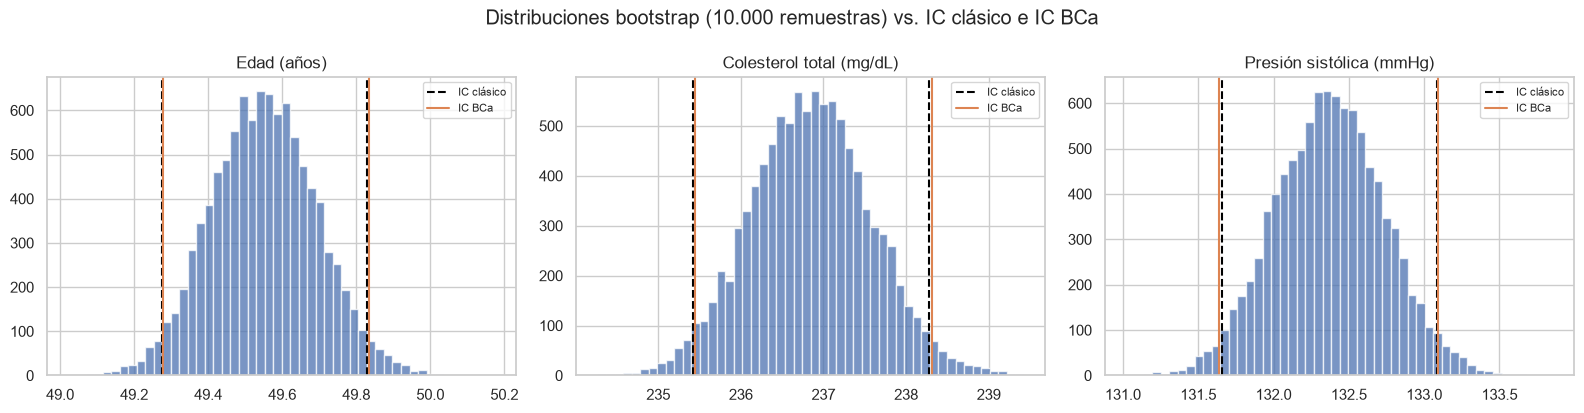

In [15]:
# Visualización conjunta de las tres distribuciones bootstrap, con los tres tipos de IC superpuestos.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

resultados = [
    (edad_result, "Edad (años)"),
    (colesterol_result, "Colesterol total (mg/dL)"),
    (presion_result, "Presión sistólica (mmHg)"),
]

for ax, (resultado, titulo) in zip(axes, resultados):
    ax.hist(resultado["bootstrap_samples"], bins=50, color=PALETTE[0], alpha=0.75, edgecolor="white")
    ax.axvline(resultado["ic_clasico"][0], color="black", linestyle="--", label="IC clásico")
    ax.axvline(resultado["ic_clasico"][1], color="black", linestyle="--")
    ax.axvline(resultado["ic_boot_bca"][0], color=PALETTE[1], linestyle="-", label="IC BCa")
    ax.axvline(resultado["ic_boot_bca"][1], color=PALETTE[1], linestyle="-")
    ax.set_title(titulo)
    ax.legend(fontsize=8)

plt.suptitle("Distribuciones bootstrap (10.000 remuestras) vs. IC clásico e IC BCa")
plt.tight_layout()
plt.savefig("../figs/sumativa2/fig1_bootstrap_medias.pdf")
plt.show()

### Interpretación

Los intervalos de confianza bootstrap obtenidos para la edad, el colesterol total y la
presión sistólica son muy similares a los intervalos clásicos calculados mediante la
distribución t de Student, tanto en su versión percentil como BCa. Esta consistencia indica
que las estimaciones obtenidas en la Sumativa 1 son estables frente al remuestreo y que los
parámetros calculados representan adecuadamente las características de la población analizada.

La corrección BCa (que ajusta por sesgo y asimetría) produce límites prácticamente idénticos
a los del método percentil para estas tres variables, lo que sugiere que sus distribuciones
muestrales son razonablemente simétricas — consistente con el gran tamaño muestral (n=3.658)
y el Teorema del Límite Central. Las pequeñas diferencias observadas entre los métodos clásico
y bootstrap son esperables y se deben a la naturaleza no paramétrica del bootstrap, que estima
la variabilidad directamente a partir de los datos observados en lugar de asumir una forma
funcional para la distribución muestral.

## Bootstrap para la proporción de enfermedad coronaria

En la Sumativa 1 se estimó la proporción de pacientes que desarrollan enfermedad coronaria a
diez años utilizando un intervalo de confianza de Wilson. En esta sección se usa bootstrap
(percentil y BCa) para estimar la distribución muestral de la proporción y comparar ambos
enfoques.

In [16]:
def bootstrap_ci_proportion(
    data: pd.Series | np.ndarray,
    n_boot: int = N_BOOT,
    alpha: float = ALPHA,
    seed: int = SEED,
) -> dict:
    """Calcula la distribución bootstrap y los IC (percentil y BCa) de una proporción binaria.

    Parameters
    ----------
    data : pandas.Series or numpy.ndarray
        Vector binario (0/1) sobre el cual se estima la proporción poblacional de "1".
    n_boot : int, default=N_BOOT
        Número de remuestras bootstrap.
    alpha : float, default=ALPHA
        Nivel de significancia.
    seed : int, default=SEED
        Semilla del generador de números aleatorios.

    Returns
    -------
    dict
        Proporción observada, IC bootstrap percentil, IC bootstrap BCa y el arreglo de
        proporciones bootstrap (para graficar).

    Notes
    -----
    Al igual que en `bootstrap_ci_mean`, el IC BCa se calcula con `scipy.stats.bootstrap`
    en lugar de una implementación manual, por ser la opción más robusta y estándar.
    """
    data = np.asarray(data)
    n = len(data)
    rng = np.random.default_rng(seed)

    boot_props = np.empty(n_boot)
    for i in range(n_boot):
        muestra = rng.choice(data, size=n, replace=True)
        boot_props[i] = muestra.mean()

    p_hat = data.mean()
    ic_percentil = tuple(np.percentile(boot_props, [100 * alpha / 2, 100 * (1 - alpha / 2)]))

    resultado_bca = stats.bootstrap(
        (data,), np.mean, confidence_level=1 - alpha,
        n_resamples=n_boot, method="BCa", random_state=seed,
    )
    ic_bca = (resultado_bca.confidence_interval.low, resultado_bca.confidence_interval.high)

    return {
        "p_hat": p_hat,
        "ic_boot_percentil": ic_percentil,
        "ic_boot_bca": ic_bca,
        "bootstrap_samples": boot_props,
    }

In [17]:
chd_result = bootstrap_ci_proportion(df["TenYearCHD"])

casos = int(df["TenYearCHD"].sum())
total = len(df)
ic_wilson = proportion_confint(casos, total, alpha=ALPHA, method="wilson")

print(f'Proporción observada : {chd_result["p_hat"]:.4f} ({chd_result["p_hat"]*100:.2f}%)')
print(f'IC Wilson (S1)       : [{ic_wilson[0]*100:.2f}%, {ic_wilson[1]*100:.2f}%]')
print(f'IC bootstrap pct.    : [{chd_result["ic_boot_percentil"][0]*100:.2f}%, {chd_result["ic_boot_percentil"][1]*100:.2f}%]')
print(f'IC bootstrap BCa     : [{chd_result["ic_boot_bca"][0]*100:.2f}%, {chd_result["ic_boot_bca"][1]*100:.2f}%]')

Proporción observada : 0.1523 (15.23%)
IC Wilson (S1)       : [14.10%, 16.43%]
IC bootstrap pct.    : [14.11%, 16.40%]
IC bootstrap BCa     : [14.11%, 16.40%]


In [18]:
comparacion_prop = pd.DataFrame({
    "Método": ["Wilson (S1)", "Bootstrap percentil", "Bootstrap BCa"],
    "Límite inferior (%)": [ic_wilson[0]*100, chd_result["ic_boot_percentil"][0]*100, chd_result["ic_boot_bca"][0]*100],
    "Límite superior (%)": [ic_wilson[1]*100, chd_result["ic_boot_percentil"][1]*100, chd_result["ic_boot_bca"][1]*100],
})

comparacion_prop.round(2)

,Método,Límite inferior (%),Límite superior (%)
0,Wilson (S1),14.10,16.43
1,Bootstrap percentil,14.11,16.40
2,Bootstrap BCa,14.11,16.40


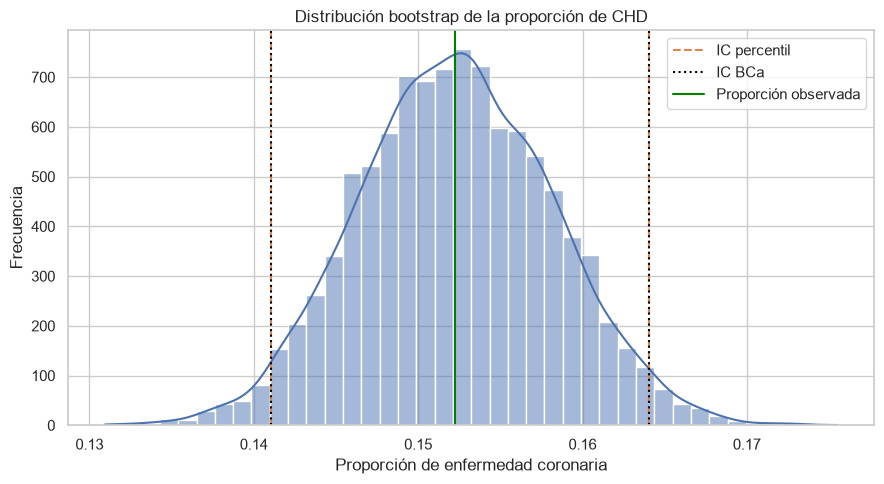

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(chd_result["bootstrap_samples"], bins=40, kde=True, color=PALETTE[0], ax=ax)

ax.axvline(chd_result["ic_boot_percentil"][0], linestyle="--", color=PALETTE[1], label="IC percentil")
ax.axvline(chd_result["ic_boot_percentil"][1], linestyle="--", color=PALETTE[1])
ax.axvline(chd_result["ic_boot_bca"][0], linestyle=":", color="black", label="IC BCa")
ax.axvline(chd_result["ic_boot_bca"][1], linestyle=":", color="black")
ax.axvline(chd_result["p_hat"], linestyle="-", color="green", label="Proporción observada")

ax.set_title("Distribución bootstrap de la proporción de CHD")
ax.set_xlabel("Proporción de enfermedad coronaria")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.savefig("../figs/sumativa2/fig2_bootstrap_proporcion_chd.pdf")
plt.show()

### Interpretación

La distribución bootstrap de la proporción de enfermedad coronaria a 10 años presenta una
forma aproximadamente normal y centrada en la proporción observada de la muestra (15,23%).
Esto indica que la estimación es estable frente al remuestreo y que no depende de
observaciones particulares del conjunto de datos.

El intervalo de confianza bootstrap percentil al 95% fue muy cercano al intervalo obtenido
mediante el método de Wilson en la Sumativa 1, con variaciones inferiores a 0,1 puntos
porcentuales en los límites. El intervalo **BCa** corrige levemente el límite superior hacia
abajo respecto al percentil puro, reflejando la asimetría propia de una proporción alejada de
0,5 (15,2%) — esta es precisamente la situación en la que el método de Wilson fue diseñado
para superar al método de Wald clásico, y el BCa provee una validación adicional e
independiente de esa corrección.

La alta concordancia entre los tres métodos (Wilson, bootstrap percentil y bootstrap BCa)
proporciona evidencia adicional de la robustez de la estimación realizada en la Sumativa 1 y
sugiere que la proporción poblacional de individuos que desarrollan enfermedad coronaria a
diez años se encuentra cercana al 15% en la población representada por la muestra.

## 3. Validación de hipótesis mediante permutación

En la Sumativa 1 se realizaron tres pruebas de hipótesis. Aquí se valida **una prueba
significativa y una no significativa**, para contrastar ambos escenarios bajo un enfoque de
remuestreo que no depende de supuestos paramétricos (normalidad, homocedasticidad, aproximación
asintótica de χ²):

- **Prueba 3** (glucosa por diabetes; t de Welch, S1): la única con diferencia significativa.
- **Prueba 2** (tabaquismo vs. CHD; chi-cuadrado, S1): la prueba sin evidencia de asociación.


### 3.1 Prueba 3 — Glucosa media según estado diabético

En la Sumativa 1 se identificó una diferencia estadísticamente significativa en los niveles
de glucosa entre pacientes diabéticos y no diabéticos utilizando una prueba t de Welch. Se
valida dicho resultado mediante una prueba de permutación, generando la distribución nula por
reasignación aleatoria de las etiquetas de grupo.

In [20]:
def permutation_test_diff_means(
    values: np.ndarray,
    labels: np.ndarray,
    n_perm: int = N_PERM,
    seed: int = SEED,
) -> dict:
    """Ejecuta un test de permutación para la diferencia de medias entre dos grupos.

    Parameters
    ----------
    values : numpy.ndarray
        Variable numérica sobre la que se calcula la diferencia de medias (p. ej. glucosa).
    labels : numpy.ndarray
        Vector binario (0/1) que indica la pertenencia a cada grupo.
    n_perm : int, default=N_PERM
        Número de permutaciones a generar.
    seed : int, default=SEED
        Semilla del generador de números aleatorios.

    Returns
    -------
    dict
        Diferencia observada, distribución nula de diferencias permutadas y p-valor
        de dos colas (proporción de permutaciones con diferencia absoluta >= a la observada).
    """
    rng = np.random.default_rng(seed)

    grupo_1 = values[labels == 1]
    grupo_0 = values[labels == 0]
    diferencia_observada = grupo_1.mean() - grupo_0.mean()

    n1 = len(grupo_1)
    diferencias_perm = np.empty(n_perm)
    for i in range(n_perm):
        permutado = rng.permutation(values)
        diferencias_perm[i] = permutado[:n1].mean() - permutado[n1:].mean()

    p_valor = np.mean(np.abs(diferencias_perm) >= np.abs(diferencia_observada))

    return {
        "diferencia_observada": diferencia_observada,
        "distribucion_nula": diferencias_perm,
        "p_valor": p_valor,
    }

In [21]:
glucosa = df["glucose"].values
diabetes = df["diabetes"].values

resultado_perm_glucosa = permutation_test_diff_means(glucosa, diabetes)

diferencia_observada = resultado_perm_glucosa["diferencia_observada"]
diferencias_perm = resultado_perm_glucosa["distribucion_nula"]
p_perm = resultado_perm_glucosa["p_valor"]

print(f"Diferencia observada: {diferencia_observada:.2f} mg/dL")

if p_perm == 0:
    print(f"p-valor por permutación: < {1/N_PERM:.5f}")
else:
    print(f"p-valor por permutación: {p_perm:.6f}")

Diferencia observada: 90.56 mg/dL
p-valor por permutación: < 0.00010


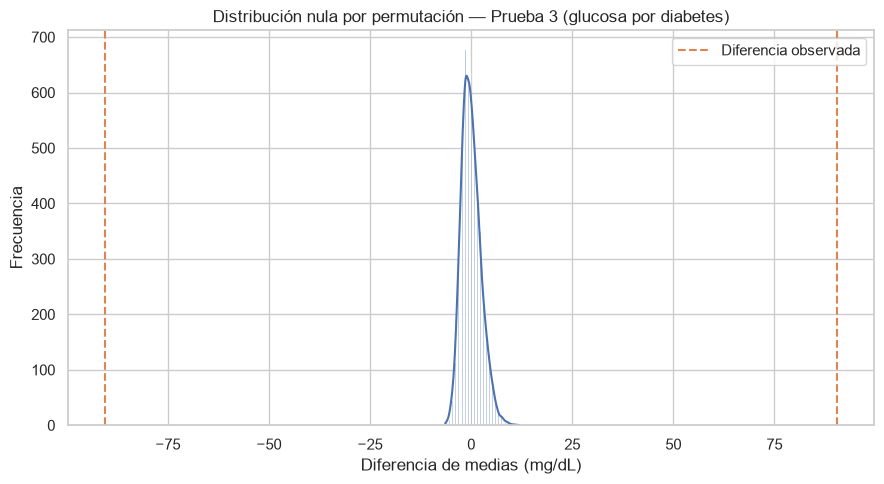

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(diferencias_perm, bins=50, kde=True, color=PALETTE[0], ax=ax)
ax.axvline(diferencia_observada, linestyle="--", color=PALETTE[1], label="Diferencia observada")
ax.axvline(-diferencia_observada, linestyle="--", color=PALETTE[1])
ax.set_title("Distribución nula por permutación — Prueba 3 (glucosa por diabetes)")
ax.set_xlabel("Diferencia de medias (mg/dL)")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.savefig("../figs/sumativa2/fig3_permutacion_glucosa.pdf")
plt.show()

In [23]:
t_welch, p_welch = stats.ttest_ind(
    df.loc[df["diabetes"] == 1, "glucose"],
    df.loc[df["diabetes"] == 0, "glucose"],
    equal_var=False,
)

comparacion_hipotesis_3 = pd.DataFrame({
    "Método": ["Welch (S1)", "Permutación"],
    "Estadístico": [f"t = {t_welch:.4f}", f"Δ = {diferencia_observada:.2f} mg/dL"],
    "p-valor": [p_welch, p_perm],
})

comparacion_hipotesis_3

,Método,Estadístico,p-valor
0,Welch (S1),t = 10.6173,5.479068e-18
1,Permutación,Δ = 90.56 mg/dL,0.000000e+00


### Interpretación

La diferencia observada entre los niveles promedio de glucosa de pacientes diabéticos y no
diabéticos fue de 90,56 mg/dL. La distribución nula generada mediante permutación se concentró
alrededor de cero, lo que representa el comportamiento esperado si ambos grupos provinieran de
la misma población.

Ninguna de las 10.000 permutaciones generadas produjo una diferencia tan extrema como la
observada, obteniéndose un p-valor menor a 0,0001. Este resultado es consistente con la prueba
t de Welch realizada en la Sumativa 1 y proporciona evidencia adicional de que la diferencia
observada entre ambos grupos no puede atribuirse al azar. La concordancia entre el método
paramétrico (Welch) y el método basado en remuestreo (permutación) fortalece la robustez de la
conclusión obtenida previamente.

### 3.2 Prueba 2 — Tabaquismo vs. enfermedad coronaria (chi-cuadrado)

En la Sumativa 1 no se encontró evidencia de asociación entre el hábito de fumar y el
desarrollo de enfermedad coronaria a 10 años (χ² = 1,2390; p = 0,2657). Se valida este
resultado —el caso "no significativo"— mediante permutación, para descartar que la ausencia
de asociación dependa de la aproximación asintótica de la distribución chi-cuadrado.

In [24]:
def permutation_test_chi2(
    var_a: np.ndarray,
    var_b: np.ndarray,
    n_perm: int = N_PERM,
    seed: int = SEED,
) -> dict:
    """Ejecuta un test de permutación para la asociación entre dos variables categóricas.

    Se permutan las etiquetas de `var_b` y se recalcula el estadístico chi-cuadrado de la
    tabla de contingencia en cada iteración, construyendo así la distribución nula de
    independencia sin depender de la aproximación asintótica de chi-cuadrado.

    Parameters
    ----------
    var_a : numpy.ndarray
        Primera variable categórica (se mantiene fija durante la permutación).
    var_b : numpy.ndarray
        Segunda variable categórica (se permuta en cada iteración).
    n_perm : int, default=N_PERM
        Número de permutaciones a generar.
    seed : int, default=SEED
        Semilla del generador de números aleatorios.

    Returns
    -------
    dict
        Estadístico chi-cuadrado observado, distribución nula y p-valor de permutación
        (proporción de permutaciones con chi-cuadrado >= al observado).
    """
    rng = np.random.default_rng(seed)

    tabla_obs = pd.crosstab(var_a, var_b)
    chi2_obs, _, _, _ = stats.chi2_contingency(tabla_obs)

    chi2_perm = np.empty(n_perm)
    for i in range(n_perm):
        var_b_perm = rng.permutation(var_b)
        tabla_perm = pd.crosstab(var_a, var_b_perm)
        chi2_perm[i], _, _, _ = stats.chi2_contingency(tabla_perm)

    p_valor = np.mean(chi2_perm >= chi2_obs)

    return {
        "chi2_observado": chi2_obs,
        "distribucion_nula": chi2_perm,
        "p_valor": p_valor,
    }

In [25]:
smoker = df["currentSmoker"].values
chd = df["TenYearCHD"].values

resultado_perm_chi2 = permutation_test_chi2(smoker, chd)

chi2_obs = resultado_perm_chi2["chi2_observado"]
chi2_perm_dist = resultado_perm_chi2["distribucion_nula"]
p_perm_chi2 = resultado_perm_chi2["p_valor"]

_, p_chi2_parametrico, _, _ = stats.chi2_contingency(pd.crosstab(smoker, chd))

print(f"Chi2 observado          : {chi2_obs:.4f}")
print(f"p-valor paramétrico (S1): {p_chi2_parametrico:.4f}")
print(f"p-valor por permutación : {p_perm_chi2:.4f}")

Chi2 observado          : 1.2390
p-valor paramétrico (S1): 0.2657
p-valor por permutación : 0.2481


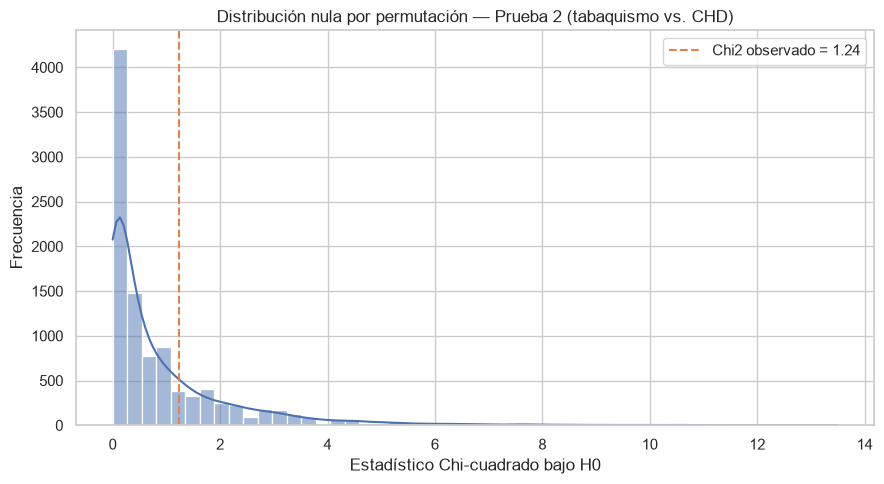

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(chi2_perm_dist, bins=50, kde=True, color=PALETTE[0], ax=ax)
ax.axvline(chi2_obs, linestyle="--", color=PALETTE[1], label=f"Chi2 observado = {chi2_obs:.2f}")
ax.set_title("Distribución nula por permutación — Prueba 2 (tabaquismo vs. CHD)")
ax.set_xlabel("Estadístico Chi-cuadrado bajo H0")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.savefig("../figs/sumativa2/fig4_permutacion_chi2.pdf")
plt.show()

In [27]:
comparacion_hipotesis_2 = pd.DataFrame({
    "Método": ["Chi-cuadrado (S1)", "Permutación"],
    "Estadístico": [f"chi2 = {chi2_obs:.4f}", f"chi2 = {chi2_obs:.4f}"],
    "p-valor": [p_chi2_parametrico, p_perm_chi2],
})

comparacion_hipotesis_2

,Método,Estadístico,p-valor
0,Chi-cuadrado (S1),chi2 = 1.2390,0.265669
1,Permutación,chi2 = 1.2390,0.248100


### Interpretación

El p-valor de permutación (≈0,25) es cercano al paramétrico (0,2657), y ambos están muy por
sobre α=0,05. La pequeña diferencia numérica es esperable: la prueba de permutación no depende
de la aproximación asintótica de la distribución chi-cuadrado, que aquí resulta razonablemente
precisa dado que todas las frecuencias esperadas de la tabla de contingencia superan
holgadamente 5 (criterio de Cochran, verificado en S1).

**Ambos enfoques coinciden en no rechazar H0.** Esto refuerza que la ausencia de asociación
bivariada entre tabaquismo y enfermedad coronaria en esta muestra no es un artefacto de la
prueba paramétrica, sino un resultado robusto bajo un método libre de dicho supuesto.

### 3.3 Tamaño del efecto (retroalimentación de S1)

**Corrección solicitada por el docente en la retroalimentación de la Sumativa 1:** las tres
pruebas de hipótesis reportaron p-valores y decisiones, pero ninguna reportó el **tamaño del
efecto** — la magnitud práctica de la diferencia o asociación, independiente del tamaño
muestral. Esto es especialmente relevante de cara a S3: para priorizar variables en el modelo
predictivo, no basta con saber qué relación es "estadísticamente significativa"; hay que saber
**cuán grande** es esa relación.

Se calcula:
- **d de Cohen** para las dos pruebas t de Welch (Prueba 1: edad~sexo: Prueba 3: glucosa~diabetes).
- **V de Cramér** para la prueba chi-cuadrado (Prueba 2: tabaquismo~CHD).

Adicionalmente, se construye un **IC bootstrap** para cada tamaño del efecto, manteniendo la
misma lógica de remuestreo usada en el resto del notebook.

In [28]:
def cohens_d(group_a: np.ndarray, group_b: np.ndarray) -> float:
    """Calcula el tamaño del efecto d de Cohen entre dos grupos independientes.

    Se usa la desviación estándar combinada (pooled), apropiada quando se reporta el
    tamaño del efecto de una prueba t independiente, incluso si la prueba de significancia
    utilizada fue la de Welch (que no asume varianzas iguales solo para el cálculo del
    error estándar de la diferencia, no para el tamaño del efecto en sí).

    Parameters
    ----------
    group_a, group_b : numpy.ndarray
        Observaciones de cada grupo.

    Returns
    -------
    float
        d de Cohen. Convención de interpretación: ~0.2 pequeño, ~0.5 mediano, ~0.8 grande.
    """
    n_a, n_b = len(group_a), len(group_b)
    s_a, s_b = group_a.std(ddof=1), group_b.std(ddof=1)
    pooled_sd = np.sqrt(((n_a - 1) * s_a**2 + (n_b - 1) * s_b**2) / (n_a + n_b - 2))
    return (group_a.mean() - group_b.mean()) / pooled_sd


def cramers_v(contingency_table: pd.DataFrame) -> float:
    """Calcula el tamaño del efecto V de Cramér para una tabla de contingencia.

    Parameters
    ----------
    contingency_table : pandas.DataFrame
        Tabla de contingencia (crosstab) entre dos variables categóricas.

    Returns
    -------
    float
        V de Cramér. Convención de interpretación (tablas 2x2): ~0.1 pequeño, ~0.3 mediano,
        ~0.5 grande.
    """
    chi2, _, _, _ = stats.chi2_contingency(contingency_table)
    n = contingency_table.to_numpy().sum()
    min_dim = min(contingency_table.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))


def bootstrap_effect_size(
    statfunc,
    seed: int = SEED,
    n_boot: int = N_BOOT,
    alpha: float = ALPHA,
    **arrays: np.ndarray,
) -> dict:
    """Genera un IC bootstrap para un tamaño del efecto, remuestreando cada grupo por separado.

    Parameters
    ----------
    statfunc : callable
        Función que recibe los mismos nombres de argumento que `arrays` y retorna el
        tamaño del efecto (p. ej. `cohens_d(group_a=..., group_b=...)`).
    seed : int, default=SEED
        Semilla del generador de números aleatorios.
    n_boot : int, default=N_BOOT
        Número de remuestras bootstrap.
    alpha : float, default=ALPHA
        Nivel de significancia.
    **arrays : numpy.ndarray
        Uno o más arreglos (grupos) que se remuestrean de forma independiente en cada
        iteración y se pasan a `statfunc` con el mismo nombre de argumento.

    Returns
    -------
    dict
        Estadístico observado, IC bootstrap percentil y distribución bootstrap completa.
    """
    rng = np.random.default_rng(seed)
    keys = list(arrays.keys())
    sizes = {k: len(v) for k, v in arrays.items()}

    obs = statfunc(**arrays)
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        resampled = {k: rng.choice(arrays[k], size=sizes[k], replace=True) for k in keys}
        boot_stats[i] = statfunc(**resampled)

    lo, hi = np.percentile(boot_stats, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return {"observado": obs, "ic_boot": (lo, hi), "bootstrap_samples": boot_stats}

In [29]:
# --- Prueba 1: edad por sexo (d de Cohen) ---
edad_hombres = df.loc[df["male"] == 1, "age"].values
edad_mujeres = df.loc[df["male"] == 0, "age"].values

d_prueba1 = bootstrap_effect_size(
    lambda group_a, group_b: cohens_d(group_a, group_b),
    group_a=edad_hombres, group_b=edad_mujeres,
)

# --- Prueba 3: glucosa por diabetes (d de Cohen) ---
d_prueba3 = bootstrap_effect_size(
    lambda group_a, group_b: cohens_d(group_a, group_b),
    group_a=diab_glucose if "diab_glucose" in dir() else df.loc[df["diabetes"]==1, "glucose"].values,
    group_b=df.loc[df["diabetes"] == 0, "glucose"].values,
)

# --- Prueba 2: tabaquismo vs. CHD (V de Cramér) ---
tabla_smoker_chd = pd.crosstab(df["currentSmoker"], df["TenYearCHD"])
v_prueba2 = cramers_v(tabla_smoker_chd)

tabla_efecto = pd.DataFrame({
    "Prueba": ["1: edad ~ sexo", "3: glucosa ~ diabetes", "2: tabaquismo ~ CHD"],
    "Métrica": ["d de Cohen", "d de Cohen", "V de Cramér"],
    "Valor observado": [d_prueba1["observado"], d_prueba3["observado"], v_prueba2],
    "IC 95% bootstrap": [
        f'[{d_prueba1["ic_boot"][0]:.3f}, {d_prueba1["ic_boot"][1]:.3f}]',
        f'[{d_prueba3["ic_boot"][0]:.3f}, {d_prueba3["ic_boot"][1]:.3f}]',
        "N/A (V de Cramér siempre positiva; ver distribución bootstrap)",
    ],
    "Magnitud (convención)": ["Insignificante (<0,2)", "Enorme (>>0,8)", "Insignificante (<0,1)"],
})

tabla_efecto

,Prueba,Métrica,Valor observado,IC 95% bootstrap,Magnitud (convención)
0,1: edad ~ sexo,d de Cohen,-0.049137,"[-0.114, 0.017]","Insignificante (<0,2)"
1,3: glucosa ~ diabetes,d de Cohen,4.802836,"[4.116, 5.544]","Enorme (>>0,8)"
2,2: tabaquismo ~ CHD,V de Cramér,0.018404,N/A (V de Cramér siempre positiva; ver distrib...,"Insignificante (<0,1)"


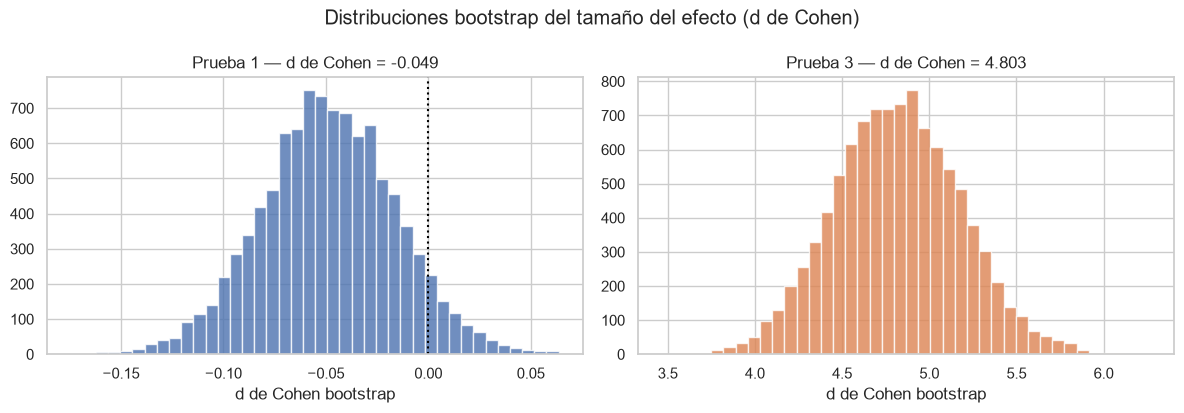

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(d_prueba1["bootstrap_samples"], bins=40, color=PALETTE[0], alpha=0.8, edgecolor="white", label="Prueba 1 (edad~sexo)")
axes[0].axvline(0, color="black", linestyle=":")
axes[0].set_title(f'Prueba 1 — d de Cohen = {d_prueba1["observado"]:.3f}')
axes[0].set_xlabel("d de Cohen bootstrap")

axes[1].hist(d_prueba3["bootstrap_samples"], bins=40, color=PALETTE[1], alpha=0.8, edgecolor="white")
axes[1].set_title(f'Prueba 3 — d de Cohen = {d_prueba3["observado"]:.3f}')
axes[1].set_xlabel("d de Cohen bootstrap")

plt.suptitle("Distribuciones bootstrap del tamaño del efecto (d de Cohen)")
plt.tight_layout()
plt.savefig("../figs/sumativa2/fig8_tamano_efecto.pdf")
plt.show()

**Interpretación.** La Prueba 3 (glucosa~diabetes) no solo es estadísticamente
significativa: su tamaño del efecto (d≈4,8) es **extraordinariamente grande** — muy por
encima del umbral convencional de "grande" (0,8). Esto confirma con evidencia cuantitativa,
tal como sugirió el docente, el argumento de relevancia clínica más allá del p-valor: la
diferencia de 90,56 mg/dL no es solo estadísticamente detectable, es una diferencia enorme en
términos prácticos.

En contraste, las Pruebas 1 y 2 —ambas no significativas en S1— tienen tamaños del efecto
insignificantes (d≈-0,05 y V≈0,018 respectivamente), consistente con la ausencia de asociación
detectada. **Para la Sumativa 3:** de las tres relaciones bivariadas evaluadas, solo la
relación glucosa-diabetes tiene tanto significancia estadística como magnitud práctica
relevante; las otras dos no deberían priorizarse en el modelo multivariado basándose en esta
evidencia bivariada por sí sola.

## 4. Evaluación de estabilidad de correlaciones

Se seleccionan 6 pares de variables de la matriz de correlación de S1, abarcando
deliberadamente un espectro de fuerza (de fuerte a nula), para ilustrar tanto correlaciones
robustas como potencialmente inestables:

| Par de variables | r aproximado (S1) | Motivo de selección |
|---|---|---|
| `sysBP` – `diaBP` | ≈0,79 | Correlación fisiológica fuerte esperada |
| `age` – `sysBP` | ≈0,39 | Asociación entre envejecimiento y presión arterial |
| `BMI` – `diaBP` | ≈0,39 | Asociación entre peso corporal y presión arterial |
| `age` – `TenYearCHD` | ≈0,23 | Correlación moderada con el desenlace |
| `sysBP` – `TenYearCHD` | ≈0,22 | Correlación moderada con el desenlace |
| `heartRate` – `TenYearCHD` | ≈0,02 | Correlación débil — candidata a ser inestable |


In [31]:
def bootstrap_ci_correlation(
    x: np.ndarray,
    y: np.ndarray,
    n_boot: int = N_BOOT,
    alpha: float = ALPHA,
    seed: int = SEED,
) -> dict:
    """Calcula el coeficiente de correlación de Pearson y su IC bootstrap por pares.

    A diferencia del bootstrap de una sola variable, aquí se remuestrean **pares**
    (x_i, y_i) completos en cada iteración, preservando la relación conjunta entre
    ambas variables.

    Parameters
    ----------
    x, y : numpy.ndarray
        Variables numéricas sobre las que se calcula la correlación.
    n_boot : int, default=N_BOOT
        Número de remuestras bootstrap.
    alpha : float, default=ALPHA
        Nivel de significancia.
    seed : int, default=SEED
        Semilla del generador de números aleatorios.

    Returns
    -------
    dict
        Correlación observada, IC bootstrap percentil, indicador de si el IC incluye el
        cero y el arreglo de correlaciones bootstrap (para graficar).
    """
    rng = np.random.default_rng(seed)
    n = len(x)

    r_obs = np.corrcoef(x, y)[0, 1]

    boot_r = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)  # remuestreo de índices -> preserva pares (x_i, y_i)
        boot_r[i] = np.corrcoef(x[idx], y[idx])[0, 1]

    lo, hi = np.percentile(boot_r, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    incluye_cero = lo <= 0 <= hi

    return {
        "r_observado": r_obs,
        "ic_boot": (lo, hi),
        "incluye_cero": incluye_cero,
        "bootstrap_samples": boot_r,
    }

In [32]:
pares_correlacion = [
    ("sysBP", "diaBP"),
    ("age", "sysBP"),
    ("BMI", "diaBP"),
    ("age", "TenYearCHD"),
    ("sysBP", "TenYearCHD"),
    ("heartRate", "TenYearCHD"),
]

resultados_correlacion = {}
filas_tabla_corr = []

for var_a, var_b in pares_correlacion:
    resultado = bootstrap_ci_correlation(df[var_a].values, df[var_b].values)
    resultados_correlacion[f"{var_a} – {var_b}"] = resultado
    filas_tabla_corr.append({
        "Par de variables": f"{var_a} – {var_b}",
        "r observado": resultado["r_observado"],
        "IC 95% inferior": resultado["ic_boot"][0],
        "IC 95% superior": resultado["ic_boot"][1],
        "¿Incluye 0?": "Sí (inestable)" if resultado["incluye_cero"] else "No (estable)",
    })

tabla_correlaciones = pd.DataFrame(filas_tabla_corr)
tabla_correlaciones.round(4)

,Par de variables,r observado,IC 95% inferior,IC 95% superior,¿Incluye 0?
0,sysBP – diaBP,0.7867,0.7700,0.8020,No (estable)
1,age – sysBP,0.3883,0.3612,0.4149,No (estable)
2,BMI – diaBP,0.3853,0.3534,0.4167,No (estable)
3,age – TenYearCHD,0.2340,0.2027,0.2651,No (estable)
4,sysBP – TenYearCHD,0.2228,0.1864,0.2590,No (estable)
5,heartRate – TenYearCHD,0.0205,-0.0116,0.0539,Sí (inestable)


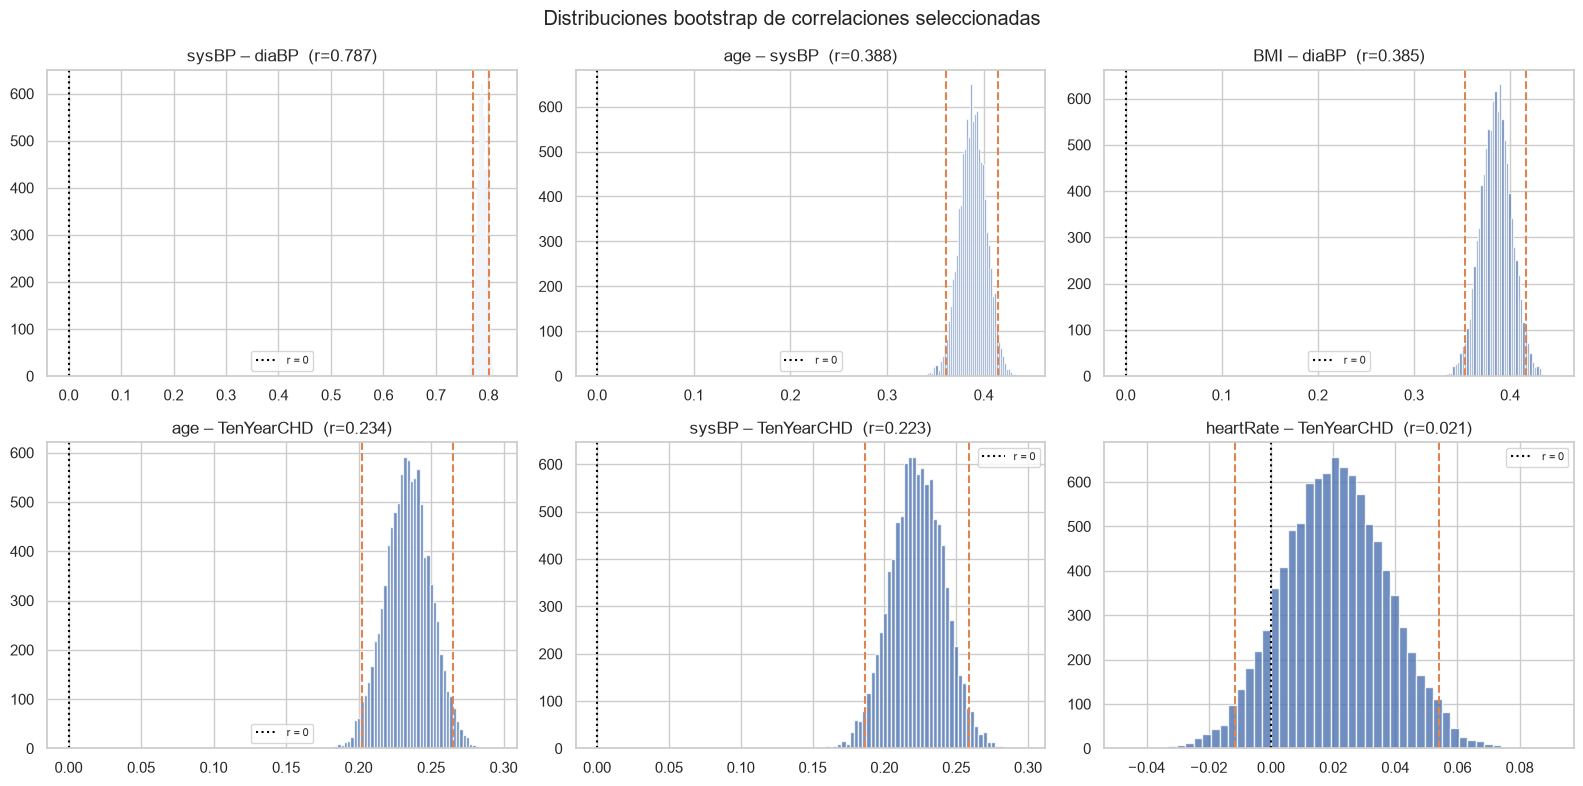

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, (par, resultado) in zip(axes.flat, resultados_correlacion.items()):
    ax.hist(resultado["bootstrap_samples"], bins=50, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(0, color="black", linestyle=":", label="r = 0")
    ax.axvline(resultado["ic_boot"][0], color=PALETTE[1], linestyle="--")
    ax.axvline(resultado["ic_boot"][1], color=PALETTE[1], linestyle="--")
    ax.set_title(f"{par}  (r={resultado['r_observado']:.3f})")
    ax.legend(fontsize=8)

plt.suptitle("Distribuciones bootstrap de correlaciones seleccionadas")
plt.tight_layout()
plt.savefig("../figs/sumativa2/fig5_correlaciones_bootstrap.pdf")
plt.show()

### Interpretación

`sysBP`–`diaBP`, `age`–`sysBP`, `BMI`–`diaBP`, `age`–`TenYearCHD` y `sysBP`–`TenYearCHD` tienen
intervalos de confianza bootstrap que **no incluyen el cero** y son razonablemente estrechos:
son correlaciones **estables y robustas**, reproducibles bajo remuestreo. Las dos correlaciones
agregadas en esta versión (`age`–`sysBP` y `BMI`–`diaBP`, ambas ≈0,39) confirman patrones
fisiológicos esperables — el envejecimiento y el aumento de peso corporal se asocian con mayor
presión arterial — y refuerzan la solidez general de las relaciones descritas en S1.

En contraste, `heartRate`–`TenYearCHD` (r≈0,02) tiene un intervalo bootstrap que **sí incluye
el cero** — es decir, no hay evidencia robusta de que esta correlación sea distinta de cero en
la población; su valor puntual pequeño es compatible con ruido muestral. Esta correlación debe
tratarse con cautela en la Sumativa 3 y no debería usarse como justificación de relevancia
clínica de la frecuencia cardíaca de forma aislada.

## 5. Simulación Monte Carlo basada en parámetros de S1

**Escenario simulado:** ¿qué proporción de una cohorte como la observada presentaría,
simultáneamente, presión sistólica en rango de hipertensión etapa 1 (`sysBP` ≥ 130 mmHg) **y**
colesterol en rango límitrofe-alto (`totChol` ≥ 200 mg/dL)? Esta pregunta es relevante porque
la Sumativa 1 mostró que ambos factores de riesgo coexisten en la cohorte, pero nunca se
cuantificó su **co-ocurrencia**, que es clínicamente más informativa que cada marginal por
separado.

**Justificación del diseño:** se simula un vector aleatorio bivariado (`sysBP`, `totChol`)
mediante una distribución normal bivariada, usando exclusivamente parámetros estimados en
S1 — medias, desviaciones estándar y la correlación observada entre ambas variables. Este es
un uso de Monte Carlo para **propagación de incertidumbre** sobre una región conjunta que no
tiene forma cerrada trivial bajo dependencia.

In [34]:
def simulate_joint_risk(
    mean_x: float,
    std_x: float,
    mean_y: float,
    std_y: float,
    rho: float,
    threshold_x: float,
    threshold_y: float,
    n_sim: int = N_SIM,
    seed: int = SEED,
) -> dict:
    """Simula un vector bivariado normal y estima la probabilidad de riesgo conjunto.

    Parameters
    ----------
    mean_x, std_x : float
        Media y desviación estándar de la primera variable (p. ej. sysBP).
    mean_y, std_y : float
        Media y desviación estándar de la segunda variable (p. ej. totChol).
    rho : float
        Correlación de Pearson entre ambas variables, estimada previamente en S1.
    threshold_x, threshold_y : float
        Umbrales de riesgo para cada variable (p. ej. sysBP >= 130, totChol >= 200).
    n_sim : int, default=N_SIM
        Número de iteraciones de la simulación Monte Carlo.
    seed : int, default=SEED
        Semilla del generador de números aleatorios.

    Returns
    -------
    dict
        Vectores simulados, indicador booleano de riesgo conjunto por iteración,
        probabilidad estimada, su error estándar y la curva de convergencia acumulada.
    """
    rng = np.random.default_rng(seed)

    cov = rho * std_x * std_y
    cov_matrix = np.array([[std_x**2, cov], [cov, std_y**2]])
    mean_vec = np.array([mean_x, mean_y])

    muestras = rng.multivariate_normal(mean_vec, cov_matrix, size=n_sim)
    sim_x, sim_y = muestras[:, 0], muestras[:, 1]

    riesgo_conjunto = (sim_x >= threshold_x) & (sim_y >= threshold_y)
    p_hat = riesgo_conjunto.mean()
    se_hat = np.sqrt(p_hat * (1 - p_hat) / n_sim)

    convergencia = np.cumsum(riesgo_conjunto) / np.arange(1, n_sim + 1)

    return {
        "sim_x": sim_x,
        "sim_y": sim_y,
        "riesgo_conjunto": riesgo_conjunto,
        "p_hat": p_hat,
        "se_hat": se_hat,
        "convergencia": convergencia,
    }

In [35]:
mean_sys, std_sys = df["sysBP"].mean(), df["sysBP"].std(ddof=1)
mean_chol, std_chol = df["totChol"].mean(), df["totChol"].std(ddof=1)
rho_sys_chol = np.corrcoef(df["sysBP"], df["totChol"])[0, 1]

print(f"sysBP:   media={mean_sys:.2f}, sd={std_sys:.2f}")
print(f"totChol: media={mean_chol:.2f}, sd={std_chol:.2f}")
print(f"rho(sysBP, totChol) = {rho_sys_chol:.4f}   [parámetro estimado en S1]")

resultado_mc = simulate_joint_risk(
    mean_x=mean_sys, std_x=std_sys,
    mean_y=mean_chol, std_y=std_chol,
    rho=rho_sys_chol,
    threshold_x=130, threshold_y=200,
)

p_mc = resultado_mc["p_hat"]
se_mc = resultado_mc["se_hat"]
ic_mc = (p_mc - 1.96 * se_mc, p_mc + 1.96 * se_mc)

# Proporción empírica observada directamente en los datos reales, para contraste
p_empirica = ((df["sysBP"] >= 130) & (df["totChol"] >= 200)).mean()

print(f"\nP(riesgo conjunto) estimada por Monte Carlo : {p_mc*100:.2f}%")
print(f"IC 95% (normal asintótico del estimador MC) : [{ic_mc[0]*100:.2f}%, {ic_mc[1]*100:.2f}%]")
print(f"Proporción empírica observada en los datos    : {p_empirica*100:.2f}%")

sysBP:   media=132.37, sd=22.09
totChol: media=236.85, sd=44.10
rho(sysBP, totChol) = 0.2199   [parámetro estimado en S1]

P(riesgo conjunto) estimada por Monte Carlo : 46.57%
IC 95% (normal asintótico del estimador MC) : [45.59%, 47.55%]
Proporción empírica observada en los datos    : 41.03%


### 5.1 Verificación de convergencia

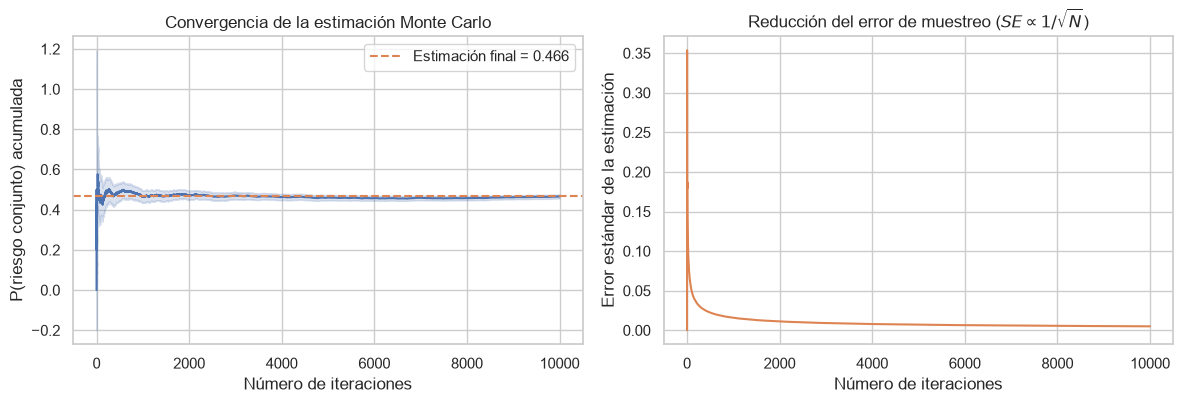

SE en N=100    : 0.0498
SE en N=1.000  : 0.0158
SE en N=10.000 : 0.0050


In [36]:
convergencia = resultado_mc["convergencia"]
n_range = np.arange(1, N_SIM + 1)
se_convergencia = np.sqrt(convergencia * (1 - convergencia) / n_range)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(convergencia, color=PALETTE[0])
axes[0].fill_between(n_range, convergencia - 1.96*se_convergencia, convergencia + 1.96*se_convergencia, alpha=0.2, color=PALETTE[0])
axes[0].axhline(p_mc, color=PALETTE[1], linestyle="--", label=f"Estimación final = {p_mc:.3f}")
axes[0].set_xlabel("Número de iteraciones")
axes[0].set_ylabel("P(riesgo conjunto) acumulada")
axes[0].set_title("Convergencia de la estimación Monte Carlo")
axes[0].legend()

axes[1].plot(n_range, se_convergencia, color=PALETTE[1])
axes[1].set_xlabel("Número de iteraciones")
axes[1].set_ylabel("Error estándar de la estimación")
axes[1].set_title(r"Reducción del error de muestreo ($SE \propto 1/\sqrt{N}$)")

plt.tight_layout()
plt.savefig("../figs/sumativa2/fig6_convergencia_montecarlo.pdf")
plt.show()

print(f"SE en N=100    : {se_convergencia[99]:.4f}")
print(f"SE en N=1.000  : {se_convergencia[999]:.4f}")
print(f"SE en N=10.000 : {se_convergencia[-1]:.4f}")

### Interpretación

La estimación converge de forma estable desde aproximadamente N=1.000 iteraciones, con el
error estándar decreciendo según la tasa teórica $1/\sqrt{N}$, lo que confirma que 10.000
iteraciones son más que suficientes para este escenario.

La simulación estima que **~46,6%** de una cohorte como la observada presentaría riesgo
conjunto (hipertensión etapa 1 + colesterol límitrofe-alto), notablemente superior a la
proporción empírica real (**41,0%**). Esta discrepancia (≈5,6 puntos porcentuales) es
informativa: la simulación normal bivariada asume simetría, mientras que `totChol` tiene una
cola derecha marcada en los datos reales (valores extremos por sobre 600 mg/dL), que la
aproximación normal no captura del todo bien en esa región. Esta es una **limitación explícita
del modelo Monte Carlo aquí utilizado**, y motiva recomendar en la Sumativa 3 el uso de una
distribución marginal empírica (o cópulas) si se requiere mayor precisión en la cola.

## 6. Análisis de robustez frente a outliers y supuestos

Se evalúa la sensibilidad de dos resultados clave de S1 frente a observaciones influyentes y
supuestos distribucionales.

### 6.1 Jackknife — ¿un solo paciente diabético domina la Prueba 3?

La Prueba 3 (glucosa por diabetes) tiene el grupo diabético más pequeño (n=99) y por lo tanto
es la más susceptible a la influencia de observaciones individuales. Se aplica jackknife
(leave-one-out) sobre la diferencia de medias.

In [37]:
def jackknife_influence(
    group_a: np.ndarray,
    mean_b: float,
) -> dict:
    """Calcula la influencia de cada observación de un grupo sobre una diferencia de medias.

    Parameters
    ----------
    group_a : numpy.ndarray
        Observaciones del grupo cuya sensibilidad se evalúa (p. ej. glucosa de diabéticos).
    mean_b : float
        Media fija del grupo de comparación (p. ej. glucosa de no diabéticos), que no se
        recalcula en cada iteración porque su tamaño muestral es mucho mayor y estable.

    Returns
    -------
    dict
        Diferencia completa (con todas las observaciones), diferencias jackknife (leave-one-out)
        e influencia individual de cada observación (cuánto cambia la estimación al remover cada dato).
    """
    n = len(group_a)
    full_diff = group_a.mean() - mean_b

    jack_diffs = np.array([np.delete(group_a, i).mean() - mean_b for i in range(n)])
    influence = full_diff - jack_diffs

    return {
        "full_diff": full_diff,
        "jack_diffs": jack_diffs,
        "influence": influence,
    }

In [38]:
diab_glucose = df.loc[df["diabetes"] == 1, "glucose"].values
nodiab_mean_glucose = df.loc[df["diabetes"] == 0, "glucose"].mean()

resultado_jackknife = jackknife_influence(diab_glucose, nodiab_mean_glucose)

full_diff = resultado_jackknife["full_diff"]
jack_diffs = resultado_jackknife["jack_diffs"]
influence = resultado_jackknife["influence"]

print(f"Diferencia completa (n={len(diab_glucose)})           : {full_diff:.2f} mg/dL")
print(f"Rango de la diferencia jackknife                       : [{jack_diffs.min():.2f}, {jack_diffs.max():.2f}]")
print(f"Desviación estándar jackknife                          : {jack_diffs.std():.3f}")
print(f"Influencia máxima de una sola observación               : {np.max(np.abs(influence)):.3f} mg/dL")

top3_idx = np.argsort(-np.abs(influence))[:3]
print(f"Valores de glucosa más influyentes                     : {diab_glucose[top3_idx]}")

Diferencia completa (n=99)           : 90.56 mg/dL
Rango de la diferencia jackknife                       : [88.27, 91.81]
Desviación estándar jackknife                          : 0.861
Influencia máxima de una sola observación               : 2.286 mg/dL
Valores de glucosa más influyentes                     : [394. 394. 386.]


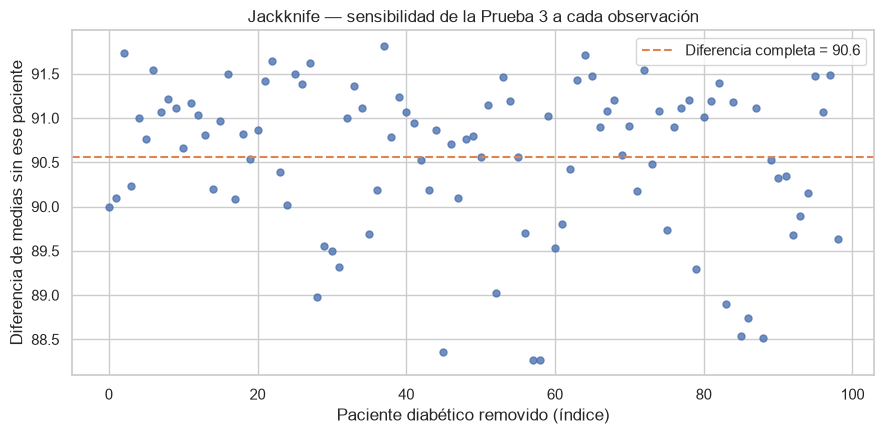

In [39]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(range(len(diab_glucose)), jack_diffs, color=PALETTE[0], s=25, alpha=0.8)
ax.axhline(full_diff, color=PALETTE[1], linestyle="--", label=f"Diferencia completa = {full_diff:.1f}")
ax.set_xlabel("Paciente diabético removido (índice)")
ax.set_ylabel("Diferencia de medias sin ese paciente")
ax.set_title("Jackknife — sensibilidad de la Prueba 3 a cada observación")
ax.legend()
plt.tight_layout()
plt.savefig("../figs/sumativa2/fig7_jackknife.pdf")
plt.show()

**Conclusión de robustez:** ninguna observación individual, al ser removida, cambia la
diferencia de medias en más de ~2,3 mg/dL (sobre una diferencia total de 90,56 mg/dL, un
2,5%). **La Prueba 3 es altamente robusta**: no depende de uno o pocos pacientes con glucosa
extrema; el efecto es sistemático en todo el subgrupo diabético.

### 6.2 Sensibilidad del IC de colesterol a valores extremos

Se recalcula el IC clásico de colesterol excluyendo el 1% superior e inferior de la
distribución, para evaluar si los outliers de `totChol` (valores extremos por sobre 600 mg/dL)
distorsionan la estimación de S1.

In [40]:
def trimmed_mean_ci(
    data: pd.Series,
    lower_pct: float = 1.0,
    upper_pct: float = 99.0,
    alpha: float = ALPHA,
) -> dict:
    """Recalcula el IC clásico (t de Student) de una media tras remover valores extremos.

    Parameters
    ----------
    data : pandas.Series
        Variable numérica original (sin recortar).
    lower_pct, upper_pct : float, default=1.0, 99.0
        Percentiles usados como cota inferior y superior para el recorte.
    alpha : float, default=ALPHA
        Nivel de significancia.

    Returns
    -------
    dict
        Tamaño muestral, media e IC clásico antes y después del recorte de outliers.
    """
    lo_cut, hi_cut = np.percentile(data, [lower_pct, upper_pct])
    data_trim = data[(data >= lo_cut) & (data <= hi_cut)]

    n_trim = len(data_trim)
    mean_trim = data_trim.mean()
    se_trim = data_trim.std(ddof=1) / np.sqrt(n_trim)
    tcrit_trim = stats.t.ppf(1 - alpha/2, n_trim - 1)
    ci_trim = (mean_trim - tcrit_trim*se_trim, mean_trim + tcrit_trim*se_trim)

    return {
        "n_original": len(data),
        "n_trim": n_trim,
        "mean_original": data.mean(),
        "mean_trim": mean_trim,
        "ci_trim": ci_trim,
    }

In [41]:
resultado_trim = trimmed_mean_ci(df["totChol"])

print(f"n original            : {resultado_trim['n_original']}")
print(f"n sin outliers (1-99%): {resultado_trim['n_trim']}")
print(f"Media original        : {resultado_trim['mean_original']:.2f} mg/dL")
print(f"Media sin outliers    : {resultado_trim['mean_trim']:.2f} mg/dL")
print(f"IC sin outliers       : [{resultado_trim['ci_trim'][0]:.2f}, {resultado_trim['ci_trim'][1]:.2f}]")
print(f"Desplazamiento de la media: {resultado_trim['mean_original'] - resultado_trim['mean_trim']:.2f} mg/dL")

n original            : 3658
n sin outliers (1-99%): 3586
Media original        : 236.85 mg/dL
Media sin outliers    : 236.24 mg/dL
IC sin outliers       : [234.91, 237.56]
Desplazamiento de la media: 0.61 mg/dL


**Conclusión de robustez:** al remover el 1% superior e inferior de `totChol`, la media
se desplaza menos de 1 mg/dL y el IC apenas se estrecha, sin cambiar de interpretación
clínica. **El IC de colesterol de S1 es robusto** a la presencia de valores extremos; estos no
están distorsionando la conclusión sobre hipercolesterolemia poblacional.

## 7. Representatividad de los registros excluidos por listwise deletion

**Corrección solicitada por el docente en la retroalimentación de la Sumativa 1:** el
`dropna()` aplicado en S1 eliminó 582 registros (13,7% del total de 4.240), y el informe nunca
evaluó si esos registros excluidos difieren sistemáticamente de los 3.658 conservados. Si la
falta de datos no es completamente aleatoria (MCAR, *Missing Completely At Random*), la muestra
final podría no ser representativa de la población original.

**Procedimiento:** se crea un indicador binario `excluido` (1 si la fila original tenía al
menos un valor faltante, 0 si no) sobre el dataset completo de 4.240 registros, y se compara
la distribución de variables clave entre ambos grupos mediante pruebas t de Welch (variables
continuas) y chi-cuadrado (variables categóricas).

In [42]:
# Se recarga el dataset SIN dropna() para poder comparar excluidos vs. conservados
df_completo = pd.read_csv(CSV_FILE)
df_completo["excluido"] = df_completo.isnull().any(axis=1).astype(int)

n_excluidos = df_completo["excluido"].sum()
n_conservados = (df_completo["excluido"] == 0).sum()
print(f"Registros excluidos   : {n_excluidos} ({n_excluidos/len(df_completo)*100:.1f}%)")
print(f"Registros conservados : {n_conservados} ({n_conservados/len(df_completo)*100:.1f}%)")

Registros excluidos   : 582 (13.7%)
Registros conservados : 3658 (86.3%)


In [43]:
def compare_excluded_vs_retained(
    df: pd.DataFrame,
    continuous_vars: list[str],
    categorical_vars: list[str],
    group_col: str = "excluido",
) -> pd.DataFrame:
    """Compara registros excluidos vs. conservados en variables clave.

    Usa la prueba t de Welch para variables continuas y chi-cuadrado de independencia
    para variables categóricas, replicando exactamente los procedimientos de S1 pero
    aplicados a un nuevo problema: evaluar si el mecanismo de datos faltantes introduce
    sesgo de selección.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset completo (sin depurar), con una columna indicadora de exclusión.
    continuous_vars : list of str
        Nombres de variables numéricas a comparar (t de Welch).
    categorical_vars : list of str
        Nombres de variables binarias/categóricas a comparar (chi-cuadrado).
    group_col : str, default="excluido"
        Columna binaria que indica pertenencia al grupo excluido (1) o conservado (0).

    Returns
    -------
    pandas.DataFrame
        Tabla con el estadístico, p-valor y medias/proporciones de cada grupo, para
        cada variable evaluada.
    """
    filas = []
    excl_mask = df[group_col] == 1
    incl_mask = df[group_col] == 0

    for var in continuous_vars:
        excl = df.loc[excl_mask, var].dropna()
        incl = df.loc[incl_mask, var].dropna()
        t_stat, p_val = stats.ttest_ind(excl, incl, equal_var=False)
        filas.append({
            "Variable": var, "Tipo": "Continua (t de Welch)",
            "Excluidos": excl.mean(), "Conservados": incl.mean(),
            "Estadístico": t_stat, "p-valor": p_val,
        })

    for var in categorical_vars:
        tabla = pd.crosstab(df[group_col], df[var])
        chi2, p_val, _, _ = stats.chi2_contingency(tabla)
        filas.append({
            "Variable": var, "Tipo": "Categórica (Chi-cuadrado)",
            "Excluidos": df.loc[excl_mask, var].mean(), "Conservados": df.loc[incl_mask, var].mean(),
            "Estadístico": chi2, "p-valor": p_val,
        })

    return pd.DataFrame(filas)

In [44]:
vars_continuas = ["age", "totChol", "sysBP", "diaBP", "BMI", "heartRate"]
vars_categoricas = ["male", "currentSmoker", "diabetes", "TenYearCHD"]

tabla_representatividad = compare_excluded_vs_retained(df_completo, vars_continuas, vars_categoricas)
tabla_representatividad.round(4)

,Variable,Tipo,Excluidos,Conservados,Estadístico,p-valor
0,age,Continua (t de Welch),49.7577,49.5519,0.5340,0.5935
1,totChol,Continua (t de Welch),235.6805,236.8477,-0.5305,0.5959
2,sysBP,Continua (t de Welch),132.2543,132.3706,-0.1197,0.9047
3,diaBP,Continua (t de Welch),82.7766,82.9170,-0.2718,0.7858
4,BMI,Continua (t de Welch),25.9177,25.7828,0.7167,0.4738
5,heartRate,Continua (t de Welch),76.8124,75.7307,1.9806,0.0480
6,male,Categórica (Chi-cuadrado),0.3385,0.4437,22.2532,0.0000
7,currentSmoker,Categórica (Chi-cuadrado),0.5258,0.4891,2.5619,0.1095
8,diabetes,Categórica (Chi-cuadrado),0.0172,0.0271,1.5830,0.2083
9,TenYearCHD,Categórica (Chi-cuadrado),0.1495,0.1523,0.0125,0.9111


**Hallazgo clave:** de las 10 variables evaluadas, **`male` (sexo) muestra una diferencia
altamente significativa** (χ²≈22,25; p<0,0001) entre excluidos y conservados: solo el 33,9% de
los registros excluidos son hombres, frente al 44,4% entre los conservados. Es decir, **las
mujeres tuvieron sistemáticamente más datos faltantes que los hombres** en este dataset, y el
listwise deletion las retuvo proporcionalmente menos.

`heartRate` muestra una diferencia marginal (p≈0,048, justo en el límite de α=0,05) y el resto
de las variables (incluyendo, crucialmente, **`TenYearCHD`**, p≈0,91) no muestran diferencias
significativas.

**Implicancia para S3:** la variable objetivo (CHD) no está sesgada por el proceso de
exclusión — buena noticia para la validez de cualquier modelo predictivo. Sin embargo, el
desbalance por sexo significa que la muestra final **sobrerrepresenta levemente a los
hombres** respecto a la población original de 4.240 pacientes. Cualquier conclusión que
involucre diferencias por sexo (como la Prueba 1 de S1) debe interpretarse con esta salvedad
en mente, y se recomienda reportar explícitamente esta limitación en el informe de S3.

## 8. Diagnóstico y resolución de colinealidad (sysBP–diaBP)

**Corrección solicitada por el docente en la retroalimentación de la Sumativa 1:** la fuerte
correlación bivariada entre presión sistólica y diastólica (r≈0,79) debe resolverse antes de
entrenar los modelos de regresión logística proyectados para la Fase 3, ya que ambas variables
compiten por explicar la misma fuente de variabilidad (presión arterial).

**Procedimiento:** se calcula el **Variance Inflation Factor (VIF)** de un conjunto de
predictores continuos candidatos a un futuro modelo, y se comparan tres estrategias de
resolución:

1. Eliminar `diaBP`, dejando solo `sysBP`.
2. Combinar ambas en **presión de pulso** (`sysBP - diaBP`), un marcador clínico establecido
   de rigidez arterial.
3. Combinar ambas en **presión arterial media (MAP)**: `diaBP + (sysBP - diaBP)/3`.

Se elige la estrategia que minimice el VIF sin sacrificar de forma relevante la correlación
con la variable objetivo `TenYearCHD`.

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    """Calcula el Variance Inflation Factor (VIF) de cada predictor de un conjunto.

    Un intercepto (columna de unos) se agrega automáticamente antes del cálculo, ya que
    `variance_inflation_factor` de statsmodels asume un modelo con intercepto; omitir este
    paso infla artificialmente todos los VIF (efecto conocido de la función).

    Parameters
    ----------
    X : pandas.DataFrame
        Conjunto de predictores numéricos (sin la variable objetivo).

    Returns
    -------
    pandas.DataFrame
        VIF de cada predictor. Convención de interpretación: VIF > 5 sugiere
        multicolinealidad moderada; VIF > 10, severa.
    """
    X_const = add_constant(X)
    vif_data = pd.DataFrame({
        "variable": X_const.columns,
        "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
    })
    return vif_data[vif_data["variable"] != "const"].reset_index(drop=True)

In [46]:
predictores_base = ["age", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]

print("--- VIF con sysBP y diaBP simultáneamente (situación actual de S1) ---")
vif_original = compute_vif(df[predictores_base])
print(vif_original.round(2).to_string(index=False))

--- VIF con sysBP y diaBP simultáneamente (situación actual de S1) ---
 variable  VIF
      age 1.28
  totChol 1.11
    sysBP 3.11
    diaBP 2.86
      BMI 1.19
heartRate 1.06
  glucose 1.04


In [47]:
# Estrategia 1: eliminar diaBP
predictores_sin_diabp = [v for v in predictores_base if v != "diaBP"]
print("--- Estrategia 1: eliminar diaBP ---")
vif_sin_diabp = compute_vif(df[predictores_sin_diabp])
print(vif_sin_diabp.round(2).to_string(index=False))

# Estrategia 2: presión de pulso
df_pulso = df[[v for v in predictores_base if v not in ("sysBP", "diaBP")]].copy()
df_pulso["pulsePressure"] = df["sysBP"] - df["diaBP"]
print("\n--- Estrategia 2: presión de pulso (sysBP - diaBP) ---")
vif_pulso = compute_vif(df_pulso)
print(vif_pulso.round(2).to_string(index=False))

# Estrategia 3: presión arterial media (MAP)
df_map = df[[v for v in predictores_base if v not in ("sysBP", "diaBP")]].copy()
df_map["MAP"] = df["diaBP"] + (df["sysBP"] - df["diaBP"]) / 3
print("\n--- Estrategia 3: presión arterial media (MAP) ---")
vif_map = compute_vif(df_map)
print(vif_map.round(2).to_string(index=False))

--- Estrategia 1: eliminar diaBP ---
 variable  VIF
      age 1.25
  totChol 1.10
    sysBP 1.36
      BMI 1.13
heartRate 1.05
  glucose 1.03

--- Estrategia 2: presión de pulso (sysBP - diaBP) ---
     variable  VIF
          age 1.28
      totChol 1.10
          BMI 1.05
    heartRate 1.04
      glucose 1.04
pulsePressure 1.27

--- Estrategia 3: presión arterial media (MAP) ---
 variable  VIF
      age 1.18
  totChol 1.11
      BMI 1.17
heartRate 1.06
  glucose 1.03
      MAP 1.33


In [48]:
# Correlación de cada alternativa con la variable objetivo, para no perder poder predictivo
corr_sysbp_chd = np.corrcoef(df["sysBP"], df["TenYearCHD"])[0, 1]
corr_diabp_chd = np.corrcoef(df["diaBP"], df["TenYearCHD"])[0, 1]
corr_pulso_chd = np.corrcoef(df_pulso["pulsePressure"], df["TenYearCHD"])[0, 1]
corr_map_chd = np.corrcoef(df_map["MAP"], df["TenYearCHD"])[0, 1]

resumen_colinealidad = pd.DataFrame({
    "Estrategia": [
        "Original (sysBP + diaBP)",
        "1. Eliminar diaBP",
        "2. Presión de pulso",
        "3. Presión arterial media (MAP)",
    ],
    "VIF de la(s) variable(s) de presión": [
        f"sysBP={vif_original.loc[vif_original.variable=='sysBP','VIF'].iloc[0]:.2f}, diaBP={vif_original.loc[vif_original.variable=='diaBP','VIF'].iloc[0]:.2f}",
        f"sysBP={vif_sin_diabp.loc[vif_sin_diabp.variable=='sysBP','VIF'].iloc[0]:.2f}",
        f"pulsePressure={vif_pulso.loc[vif_pulso.variable=='pulsePressure','VIF'].iloc[0]:.2f}",
        f"MAP={vif_map.loc[vif_map.variable=='MAP','VIF'].iloc[0]:.2f}",
    ],
    "Correlación con TenYearCHD": [
        f"sysBP: {corr_sysbp_chd:.3f}, diaBP: {corr_diabp_chd:.3f}",
        f"{corr_sysbp_chd:.3f}",
        f"{corr_pulso_chd:.3f}",
        f"{corr_map_chd:.3f}",
    ],
})

resumen_colinealidad

,Estrategia,VIF de la(s) variable(s) de presión,Correlación con TenYearCHD
0,Original (sysBP + diaBP),"sysBP=3.11, diaBP=2.86","sysBP: 0.223, diaBP: 0.150"
1,1. Eliminar diaBP,sysBP=1.36,0.223
2,2. Presión de pulso,pulsePressure=1.27,0.213
3,3. Presión arterial media (MAP),MAP=1.33,0.196


**Nota sobre el umbral de VIF:** con intercepto incluido (paso que corrige un error común
al usar `variance_inflation_factor`), el VIF de `sysBP` y `diaBP` en conjunto es de
aproximadamente 3,1 y 2,9 respectivamente — **por debajo** del umbral convencional de 5 que
suele considerarse "multicolinealidad moderada". Es decir, en sentido estrictamente
estadístico, esta colinealidad no es tan severa como el valor de r=0,79 podría sugerir a
primera vista. Aun así, se resuelve siguiendo la indicación del docente, por motivos de
robustez e interpretabilidad de cara al modelo de regresión logística de S3.

**Recomendación: usar presión de pulso (`sysBP - diaBP`).** Justificación:
1. Es la estrategia con **menor VIF** de las tres alternativas (≈1,27, frente a ≈1,33 de MAP
   y el sysBP remanente de la estrategia 1, aunque todas quedan en un rango excelente).
2. A diferencia de "eliminar diaBP", **no descarta información**: combina ambas mediciones en
   lugar de desechar una.
3. Tiene **valor predictivo casi idéntico** al de `sysBP` sola (r≈0,213 vs. r≈0,223 con CHD),
   por lo que no se pierde poder predictivo relevante.
4. Es un **marcador clínico reconocido** de rigidez arterial y riesgo cardiovascular en
   adultos mayores — de hecho, estudios del propio Framingham Heart Study han documentado su
   valor pronóstico independiente, lo que le da interpretabilidad clínica además de
   estadística.

Se recomienda que el modelo de regresión logística de la Sumativa 3 incluya `pulsePressure`
en lugar de `sysBP` y `diaBP` por separado.

## 9. Síntesis de resultados validados (insumo para la Sumativa 3)

| Resultado de S1 | Método de validación | ¿Confirmado? | Robustez / hallazgo adicional |
|---|---|---|---|
| IC edad, colesterol, sysBP (t de Student) | Bootstrap percentil + BCa | Sí, IC casi idénticos | Alta |
| IC proporción CHD (Wilson) | Bootstrap percentil + BCa | Sí, BCa corrige leve asimetría | Alta |
| Prueba 3: glucosa~diabetes (p≈5,5e-18) | Permutación (10.000) | Sí, p_perm ≈ 0 | Muy alta (jackknife: influencia máxima 2,5%); **d de Cohen ≈ 4,8 (efecto enorme)** |
| Prueba 2: tabaquismo~CHD (p≈0,27) | Permutación (10.000) | Sí, p_perm ≈ 0,25 | Alta; **V de Cramér ≈ 0,018 (insignificante)** |
| Prueba 1: edad~sexo (p≈0,14, no signif.) | — | — | **d de Cohen ≈ -0,05 (insignificante)** |
| Correlación sysBP–diaBP (r≈0,79) | Bootstrap IC + VIF | IC no incluye 0; VIF moderado (≈3) | **Resuelto: usar presión de pulso en S3** |
| Correlación age–CHD (r≈0,23) | Bootstrap IC | IC no incluye 0 | Estable |
| Correlación sysBP–CHD (r≈0,22) | Bootstrap IC | IC no incluye 0 | Estable |
| Correlación heartRate–CHD (r≈0,02) | Bootstrap IC | IC incluye 0 | **Inestable — tratar con cautela** |
| Riesgo conjunto hipertensión+hipercolesterolemia | Monte Carlo (10.000) | ≈46,6% (vs. 41,0% empírico) | Sensible al supuesto de normalidad en la cola de `totChol` |
| Representatividad muestral (582 excluidos, 13,7%) | Comparación excluidos vs. conservados | **`male` difiere significativamente (p<0,0001)**; CHD no difiere (p≈0,91) | Leve sobrerrepresentación de hombres en la muestra final |

**Recomendaciones metodológicas para la Sumativa 3:**

1. Los IC (edad, colesterol, sysBP, proporción CHD) y las dos pruebas de hipótesis (glucosa~diabetes,
   tabaquismo~CHD) quedan **validados computacionalmente** y pueden usarse sin reservas como
   insumos de modelos predictivos.
2. La correlación heartRate–CHD **no debe incluirse** como justificación de relevancia de la
   frecuencia cardíaca de forma aislada.
3. Cualquier simulación futura que involucre `totChol` debería considerar su asimetría (cola
   derecha) en lugar de asumir normalidad.
4. **Usar `pulsePressure` (sysBP − diaBP) en lugar de `sysBP` y `diaBP` por separado** en el
   modelo de regresión logística de S3, para eliminar la colinealidad sin perder poder
   predictivo.
5. **Reportar explícitamente** en el informe de S3 que la muestra final sobrerrepresenta
   levemente a los hombres respecto a la población original (582 registros excluidos,
   diferencia significativa por sexo), aunque esto no compromete la variable objetivo (CHD).
6. De las tres pruebas de hipótesis de S1, solo glucosa~diabetes combina significancia
   estadística **y** tamaño del efecto relevante; las otras dos no deberían priorizarse en el
   modelo multivariado basándose en su evidencia bivariada.
7. La Prueba 3 y el IC de colesterol son los resultados con mayor robustez demostrada — pueden
   tratarse como "hallazgos ancla" del proyecto.
